In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

In [2]:
DATASET_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Wheat varieties dataset"


In [5]:
DATASET_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Wheat varieties dataset"

classes = os.listdir(DATASET_PATH)
classes

['urooj', 'Dilkash', 'Akbar']

In [6]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)
    class_counts[cls] = len(os.listdir(class_path))

class_counts

{'urooj': 125, 'Dilkash': 125, 'Akbar': 125}

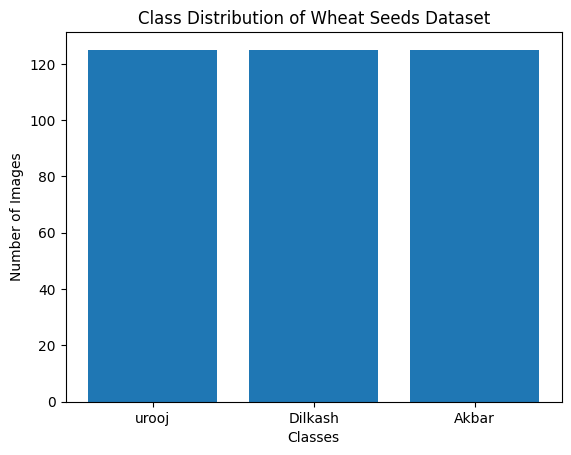

In [7]:
plt.figure()
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Wheat Seeds Dataset")
plt.show()

The class distribution indicates that the dataset is reasonably balanced across classes, with no severe imbalance observed.


The dataset contains nested subfolders within each class. Therefore, images were accessed recursively to ensure proper visualization and analysis.


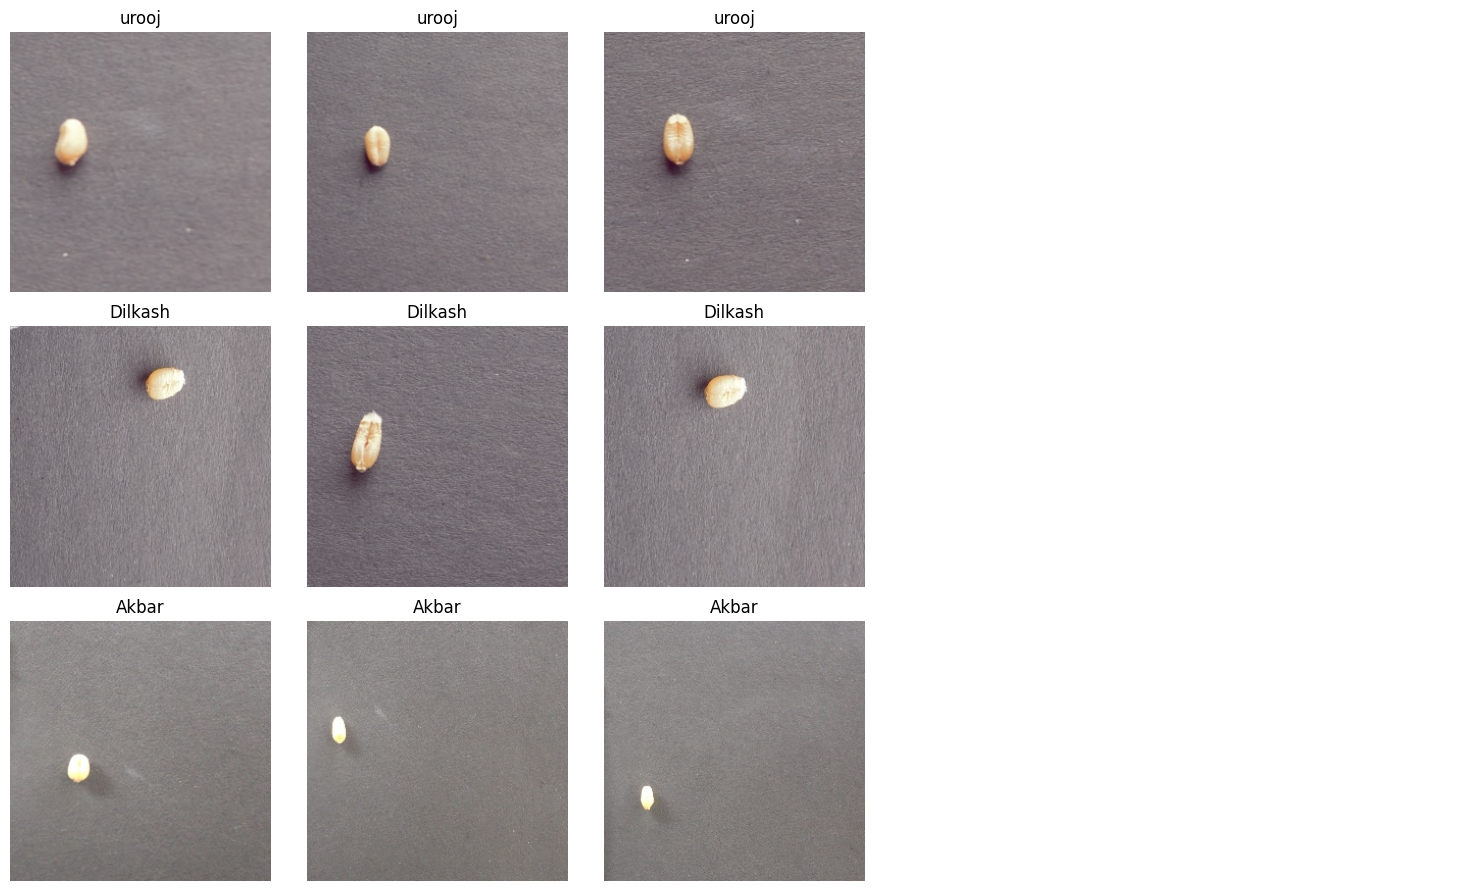

In [14]:
import matplotlib.pyplot as plt
from PIL import Image
import os

rows = len(classes)
cols = 5

fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))

for row, cls in enumerate(classes):
    class_path = os.path.join(DATASET_PATH, cls)

    images = []
    for root, dirs, files in os.walk(class_path):
        images = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if len(images) > 0:
            images = images[:cols]
            break

    for col in range(cols):
        axes[row, col].axis('off')

        if col < len(images):
            img_path = os.path.join(root, images[col])
            img = Image.open(img_path)
            axes[row, col].imshow(img)
            axes[row, col].set_title(cls)

plt.tight_layout()
plt.show()


Representative images from each class are visualized to examine intra-class variation and overall image quality.

In [19]:
widths = []
heights = []

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)

    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, file)
                img = Image.open(img_path)
                w, h = img.size
                widths.append(w)
                heights.append(h)


Image width and height statistics are collected to analyze resolution consistency across the dataset.

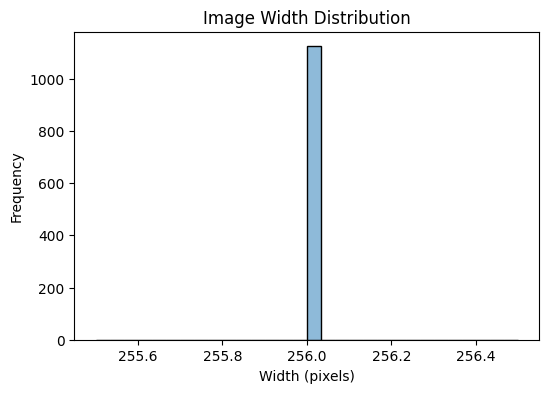

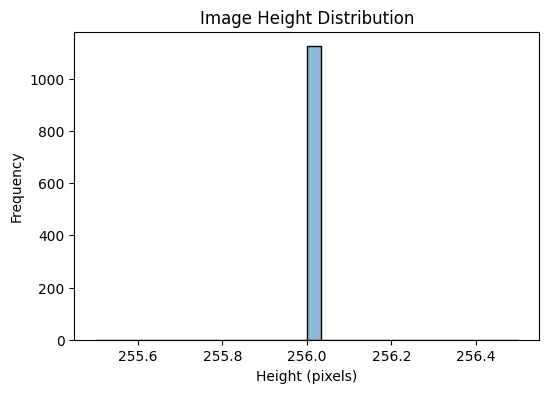

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(widths, bins=30, kde=True)
plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(heights, bins=30, kde=True)
plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")
plt.show()


Most images have similar resolutions, which allows uniform resizing during preprocessing without significant distortion.

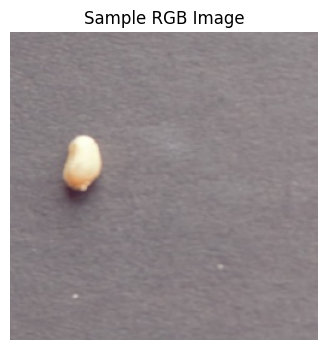

In [23]:
sample_image = None

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)
    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                sample_image = Image.open(os.path.join(root, file))
                break
        if sample_image is not None:
            break
    if sample_image is not None:
        break

# Display the image
plt.figure(figsize=(4,4))
plt.imshow(sample_image)
plt.axis('off')
plt.title("Sample RGB Image")
plt.show()


A representative sample image confirms that the dataset images are stored in RGB color format, making them suitable for CNN-based models.

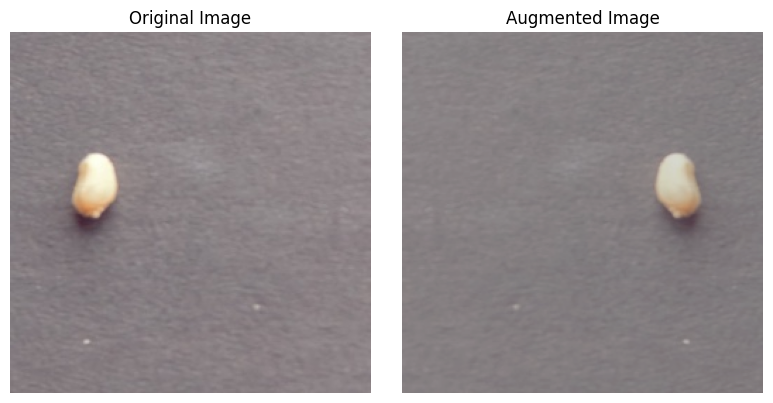

In [24]:
from torchvision import transforms

augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ColorJitter(brightness=0.3, contrast=0.3)
])

augmented_image = augmentation(sample_image)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample_image)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(augmented_image)
plt.title("Augmented Image")
plt.axis('off')

plt.tight_layout()
plt.show()


Horizontal flipping and mild color jitter preserve important seed features and are considered safe augmentations. Aggressive rotation or cropping may distort shape-based characteristics and are therefore avoided.